In [214]:
import sys
print(sys.executable)

c:\Users\Kevin\miniforge3\envs\aikb\python.exe


In [215]:
%pip install sentence-transformers pandas scikit-learn matplotlib plotly jieba

Note: you may need to restart the kernel to use updated packages.


In [216]:
import sentence_transformers, pandas, sklearn
print("environment ready")

environment ready


# 阶段 1：AI 使用画像（时间序列 EDA）

先用合成数据练手，等真实导出准备好了随时可以换成 `src/parsing/chatgpt_parser.py` 的输出。

目标表结构和解析器产出的一致：`conversation_id, turn, role, timestamp, text`。

第一步：造一份"看起来像真实使用习惯"的假数据——故意加入夜间高峰、全年增长趋势这些模式，这样后面统计出来的图才有东西可看，不是纯噪声。

In [217]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

N_CONVERSATIONS = 150
DATE_RANGE = pd.date_range("2025-01-01", "2025-12-31", freq="D")

# 模拟"夜猫子型"用户：晚上9点到凌晨1点是高峰，白天工作时段较低
HOUR_WEIGHTS = np.array([
    0.5, 0.3, 0.2, 0.1, 0.1, 0.1, 0.2, 0.3,
    0.8, 1.0, 1.0, 0.9, 0.8, 0.9, 1.0, 1.0,
    1.0, 1.2, 1.5, 2.0, 2.5, 3.0, 2.5, 1.5,
])
HOUR_WEIGHTS = HOUR_WEIGHTS / HOUR_WEIGHTS.sum()

# 全年使用量缓慢增长的趋势
DAY_WEIGHTS = np.linspace(0.5, 1.5, len(DATE_RANGE))
DAY_WEIGHTS = DAY_WEIGHTS / DAY_WEIGHTS.sum()

TOPIC_PHRASES = {
    "代码调试": ["这段代码报错了", "为什么会抛异常", "帮我看看这个bug", "怎么优化这个函数"],
    "写作润色": ["帮我润色这段话", "这句话怎么表达更自然", "帮我写一段开头"],
    "求职规划": ["这份简历怎么改", "面试官可能会问什么", "要不要跳槽"],
    "概念学习": ["能不能讲讲这个原理", "这个公式怎么推导", "这两个概念有什么区别"],
}
topics = list(TOPIC_PHRASES.keys())

rows = []
for conv_id in range(1, N_CONVERSATIONS + 1):
    day = rng.choice(DATE_RANGE, p=DAY_WEIGHTS)
    hour = rng.choice(24, p=HOUR_WEIGHTS)
    minute = rng.integers(0, 60)
    t = pd.Timestamp(day) + pd.Timedelta(hours=int(hour), minutes=int(minute))

    topic = rng.choice(topics)
    n_turns = rng.integers(2, 13)  # 2~12条消息，user/assistant交替

    for turn in range(n_turns):
        role = "user" if turn % 2 == 0 else "assistant"
        phrase = rng.choice(TOPIC_PHRASES[topic])
        rows.append({
            "conversation_id": f"conv_{conv_id:04d}",
            "turn": turn,
            "role": role,
            "timestamp": t,
            "text": f"{phrase}（{topic}，第{turn + 1}轮）",
        })
        t += pd.Timedelta(seconds=int(rng.integers(10, 300)))

df = pd.DataFrame(rows)
df.shape

(1050, 5)

## 时间特征工程

用 `.dt` 访问器从 `timestamp` 拆出 `hour`、`weekday`、`month` 三个字段。

注意 `weekday` 用 `.dt.day_name()` 拿到的是字符串（"Monday"...），后面画图时要按周一到周日的顺序排，不能直接按字母排序。

In [218]:
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.day_name()
df["month"] = df["timestamp"].dt.to_period("M").astype(str)

df[["timestamp", "hour", "weekday", "month"]].head()

,timestamp,hour,weekday,month
0,2025-11-03 17:25:00,17,Monday,2025-11
1,2025-11-03 17:26:08,17,Monday,2025-11
2,2025-10-31 21:58:00,21,Friday,2025-10
3,2025-10-31 22:00:20,22,Friday,2025-10
4,2025-10-31 22:02:17,22,Friday,2025-10


## 按星期活跃度

`day_name()` 给出的是字符串，默认按字母顺序排（Friday 排第一个），不是周一到周日。要用 `reindex` 指定顺序。

这次没在数据生成时埋星期相关的模式，所以预期这张图应该接近平的——如果跑出来某一天异常突出，大概率是代码或随机种子的问题，要回去检查，不是真的发现了规律。

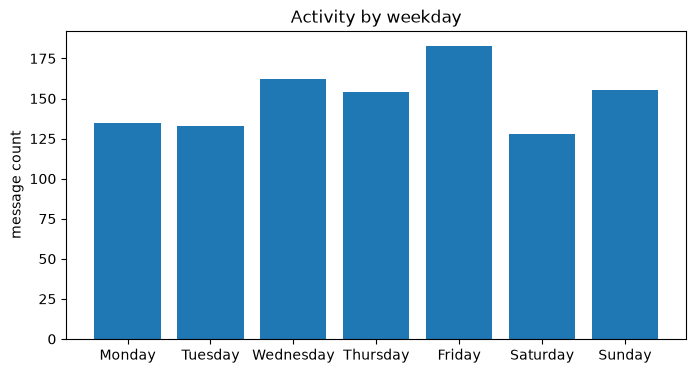

In [219]:
import matplotlib.pyplot as plt
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly = df.groupby("weekday").size().reindex(weekday_order, fill_value=0)

plt.figure(figsize=(8, 4))
plt.bar(weekly.index, weekly.values)
plt.ylabel("message count")
plt.title("Activity by weekday")
plt.show()

## 月度趋势

验证 `DAY_WEIGHTS = linspace(0.5, 1.5, ...)` 这个埋好的"全年缓慢增长"模式——按月份分组之后应该大致是一条从左到右往上走的曲线，允许月份之间有些抖动（毕竟只采样了150次对话）。

这里用折线图而不是柱状图，因为月份是有先后顺序的连续维度，看趋势用折线更直观。

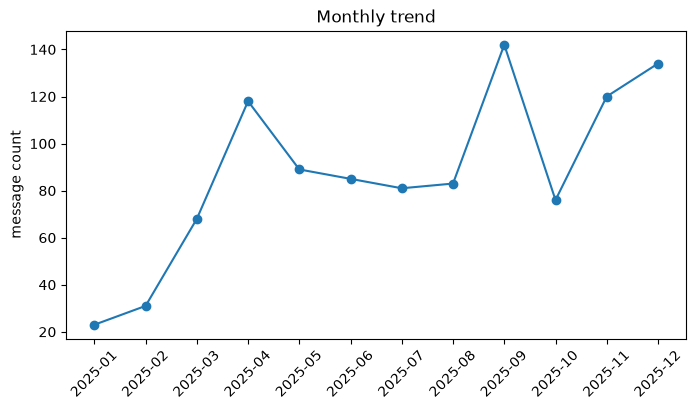

In [220]:
monthly = df.groupby("month").size().sort_index()

plt.figure(figsize=(8, 4))
plt.plot(monthly.index, monthly.values, marker="o")
plt.xticks(rotation=45)
plt.ylabel("message count")
plt.title("Monthly trend")
plt.show()

## 对话长度分布

之前几张图都是「消息级」统计，这次换成「对话级」：每个 `conversation_id` 一共有几条消息（user+assistant 加起来）。

做法：按 `conversation_id` 分组，取 `turn` 列的最大值再 +1（因为 `turn` 是从0开始计数的）。预期分布应该和生成代码里的 `n_turns = rng.integers(2, 13)` 对得上——大致在 2~12 之间均匀分布。

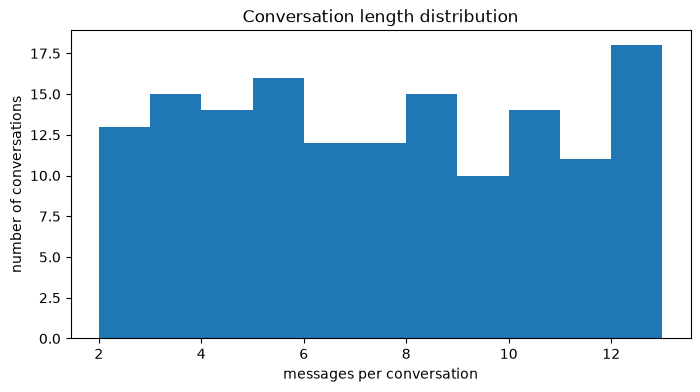

count    150.000000
mean       7.000000
std        3.250194
min        2.000000
25%        4.000000
50%        7.000000
75%       10.000000
max       12.000000
Name: turn, dtype: float64

In [221]:
conv_lengths = df.groupby("conversation_id")["turn"].max() + 1

plt.figure(figsize=(8, 4))
plt.hist(conv_lengths, bins=range(2, 14))
plt.xlabel("messages per conversation")
plt.ylabel("number of conversations")
plt.title("Conversation length distribution")
plt.show()

conv_lengths.describe()

# 阶段 2：Embedding + 聚类

把每个对话聚合成一条文档 → 编码成向量 → KMeans 聚类（elbow 选 k）→ c-TF-IDF 提主题词。

In [222]:
conv_docs = df.groupby("conversation_id")["text"].apply(lambda texts: " ".join(texts)).reset_index()
conv_docs.columns = ["conversation_id", "doc"]
conv_docs.shape, conv_docs.head(2)

((150, 2),
   conversation_id                                                doc
 0       conv_0001           这两个概念有什么区别（概念学习，第1轮） 能不能讲讲这个原理（概念学习，第2轮）
 1       conv_0002  要不要跳槽（求职规划，第1轮） 面试官可能会问什么（求职规划，第2轮） 这份简历怎么改（求职...)

In [223]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(conv_docs["doc"].tolist(), normalize_embeddings=True, show_progress_bar=True)
embeddings.shape

Batches: 100%|██████████| 5/5 [00:01<00:00,  2.51it/s]


(150, 384)

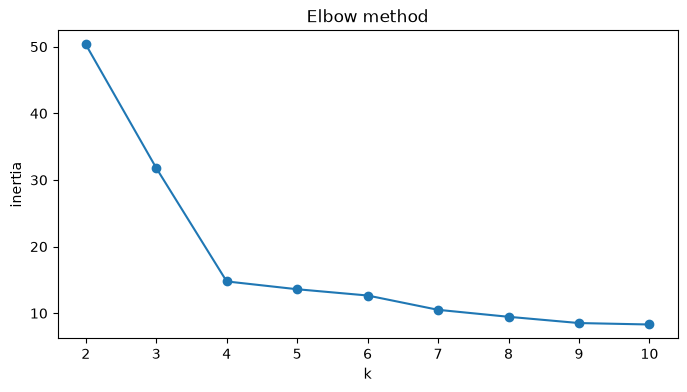

In [224]:
from sklearn.cluster import KMeans

inertias = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(embeddings)
    inertias[k] = km.inertia_

plt.figure(figsize=(8, 4))
plt.plot(list(inertias.keys()), list(inertias.values()), marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow method")
plt.show()

In [225]:
km = KMeans(n_clusters=4, random_state=42, n_init="auto")
conv_docs["cluster"] = km.fit_predict(embeddings)
conv_docs["cluster"].value_counts().sort_index()

cluster
0    37
1    39
2    39
3    35
Name: count, dtype: int64

In [226]:
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer

tokenized_docs = [" ".join(jieba.cut(doc)) for doc in conv_docs["doc"]]
vectorizer = TfidfVectorizer(max_features=2000)
tfidf = vectorizer.fit_transform(tokenized_docs)
terms = vectorizer.get_feature_names_out()

for cluster_id in sorted(conv_docs["cluster"].unique()):
    mask = (conv_docs["cluster"] == cluster_id).values
    scores = tfidf[mask].mean(axis=0).A1
    top_idx = scores.argsort()[::-1][:8]
    print(cluster_id, [terms[i] for i in top_idx])

0 ['求职', '规划', '跳槽', '不要', '可能', '面试官', '这份', '简历']
1 ['润色', '写作', '开头', '一段', '这段话', '这句', '表达', '自然']
2 ['概念学习', '这个', '推导', '公式', '概念', '区别', '两个', '讲讲']
3 ['代码', '调试', '这个', '看看', 'bug', '异常', '为什么', '函数']


# 阶段 3：语义搜索

embedding 已经归一化，cosine similarity = 点积，直接对查询向量和所有对话向量做矩阵乘法排序。

In [227]:
def search(query, top_k=3):
    query_vec = model.encode([query], normalize_embeddings=True)[0]
    scores = embeddings @ query_vec
    top_idx = scores.argsort()[::-1][:top_k]
    return conv_docs.iloc[top_idx].assign(score=scores[top_idx])

search("我应该怎么改简历")

,conversation_id,doc,cluster,score
63,conv_0064,这份简历怎么改（求职规划，第1轮） 要不要跳槽（求职规划，第2轮）,0,0.79057
67,conv_0068,要不要跳槽（求职规划，第1轮） 这份简历怎么改（求职规划，第2轮）,0,0.71166
40,conv_0041,这份简历怎么改（求职规划，第1轮） 这份简历怎么改（求职规划，第2轮）,0,0.69002


# 真实数据：阶段1~3 重跑

100个真实对话，740条消息。换掉 `df`，后面的分析代码逻辑不用变。

In [228]:
df = pd.read_parquet("../data/processed/conversations.parquet")
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.day_name()
df["month"] = df["timestamp"].dt.to_period("M").astype(str)
df.shape

(4866, 9)

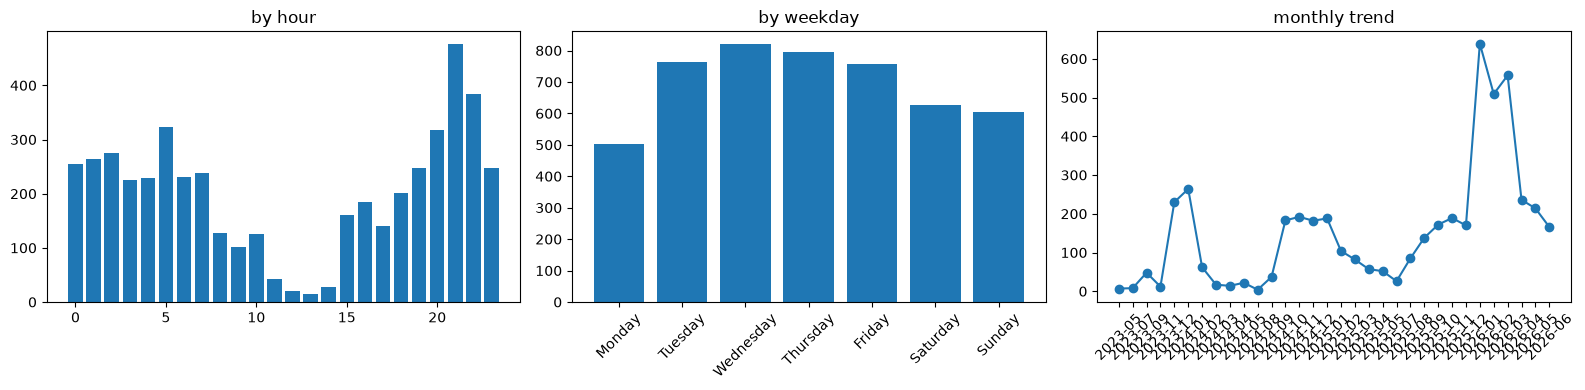

In [229]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

hourly = df.groupby("hour").size().reindex(range(24), fill_value=0)
weekly = df.groupby("weekday").size().reindex(weekday_order, fill_value=0)
monthly = df.groupby("month").size().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(hourly.index, hourly.values); axes[0].set_title("by hour")
axes[1].bar(weekly.index, weekly.values); axes[1].set_title("by weekday"); axes[1].tick_params(axis="x", rotation=45)
axes[2].plot(monthly.index, monthly.values, marker="o"); axes[2].set_title("monthly trend"); axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 真实数据：Embedding + 聚类

In [230]:
conv_docs = df.groupby("conversation_id")["text"].apply(lambda texts: " ".join(texts)).reset_index()
conv_docs.columns = ["conversation_id", "doc"]

embeddings = model.encode(conv_docs["doc"].tolist(), normalize_embeddings=True, show_progress_bar=True)
conv_docs.shape, embeddings.shape

Batches: 100%|██████████| 24/24 [00:12<00:00,  1.88it/s]


((741, 2), (741, 384))

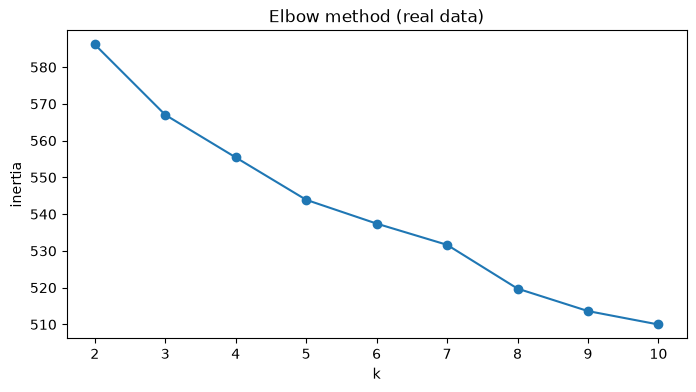

inertias: {2: 586.2, 3: 567.0, 4: 555.4, 5: 543.9, 6: 537.4, 7: 531.7, 8: 519.7, 9: 513.6, 10: 510.0}
auto-selected k: 5


In [231]:
k_range = list(range(2, 11))
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(embeddings)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow method (real data)")
plt.show()

# kneedle近似：归一化后找离首尾连线最远的点
x = np.array(k_range, dtype=float)
y = np.array(inertias, dtype=float)
x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())
line_vec = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
line_vec /= np.linalg.norm(line_vec)
distances = []
for xi, yi in zip(x_norm, y_norm):
    point_vec = np.array([xi - x_norm[0], yi - y_norm[0]])
    proj_len = np.dot(point_vec, line_vec)
    proj_point = proj_len * line_vec
    distances.append(np.linalg.norm(point_vec - proj_point))
best_k = k_range[int(np.argmax(distances))]
print("inertias:", dict(zip(k_range, [round(v, 1) for v in inertias])))
print("auto-selected k:", best_k)

In [232]:
import stopwordsiso
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

EXTRA_LATEX_NOISE = {"frac", "cdot", "dx", "dy", "dt", "sin", "cos", "tan", "theta", "vec", "text", "sqrt"}
STOPWORDS = list(ENGLISH_STOP_WORDS | stopwordsiso.stopwords("zh") | EXTRA_LATEX_NOISE)

km = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
conv_docs["cluster"] = km.fit_predict(embeddings)
print(conv_docs["cluster"].value_counts().sort_index())

tokenized_docs = [" ".join(jieba.cut(doc)) for doc in conv_docs["doc"]]
vectorizer = TfidfVectorizer(max_features=2000, stop_words=STOPWORDS)
tfidf = vectorizer.fit_transform(tokenized_docs)
terms = vectorizer.get_feature_names_out()

for cluster_id in sorted(conv_docs["cluster"].unique()):
    mask = (conv_docs["cluster"] == cluster_id).values
    scores = tfidf[mask].mean(axis=0).A1
    top_idx = scores.argsort()[::-1][:10]
    print(cluster_id, [terms[i] for i in top_idx])

cluster
0    123
1    172
2    160
3    174
4    112
Name: count, dtype: int64
0 ['cite', '日语', '00', 'ubc', 'year', '邮件', '时间', '学生', '2026', '加拿大']
1 ['step', 'int', 'approx', 'bmatrix', 'left', 'mu', 'le', 'mathbf', 'right', '10']
2 ['可能', '问题', '研究', '细胞', '影响', '基因', '建议', 'research', 'cite', '物种']
3 ['int', 'java', '逻辑', 'struct', 'void', '数组', 'cpp', '结论', '指针', '地址']
4 ['游戏', '视频', '像素', 'unity', '风格', 'windows', '角色', '素材', 'ai', 'sprite']


# 扩展使用画像：活跃天数 / 连续使用天数 / 会话时长 / 响应时间 / 语言占比

这5个字段不需要新模型，直接从已有的 `df`（真实数据，含每条消息的真实时间戳）算出来。

In [233]:
active_dates = sorted(df["timestamp"].dt.date.unique())
active_days = len(active_dates)

# 连续使用天数：把日期差转成天数，找最长的连续1天间隔的streak
gaps = pd.Series(active_dates).diff().dt.days
streak, longest_streak = 1, 1
for gap in gaps.dropna():
    streak = streak + 1 if gap == 1 else 1
    longest_streak = max(longest_streak, streak)

# 对话线程跨度 = 同一conversation_id从第一条到最后一条消息的时间跨度（可能跨多天，因为同一个对话线程可以隔几天回来接着聊）
thread_span = df.groupby("conversation_id")["timestamp"].agg(lambda x: x.max() - x.min())

# 响应时间 = 每条user消息到下一条assistant消息的时间差
df_sorted = df.sort_values(["conversation_id", "turn"])
df_sorted["next_role"] = df_sorted.groupby("conversation_id")["role"].shift(-1)
df_sorted["next_timestamp"] = df_sorted.groupby("conversation_id")["timestamp"].shift(-1)
response_times = df_sorted[(df_sorted["role"] == "user") & (df_sorted["next_role"] == "assistant")]
response_times = response_times["next_timestamp"] - response_times["timestamp"]

print("活跃天数:", active_days)
print("最长连续使用天数:", longest_streak)
print("平均对话线程跨度(从第一条消息到最后一条，可能跨多天):", thread_span.mean())
print("最长对话线程跨度:", thread_span.max(), "对话:", thread_span.idxmax())
print("平均响应时间:", response_times.mean())
print("最长响应时间:", response_times.max())

活跃天数: 411
最长连续使用天数: 39
平均对话线程跨度(从第一条消息到最后一条，可能跨多天): 0 days 06:37:24.514831908
最长对话线程跨度: 44 days 05:09:56.864522934 对话: 6a02a705-03c0-83e8-a9c7-70aba3e52996
平均响应时间: -1 days +23:23:11.043996175
最长响应时间: 0 days 00:11:01.295273066


In [234]:
from langdetect import detect, LangDetectException

def safe_detect(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df["lang"] = df["text"].apply(safe_detect)
lang_ratio = df["lang"].value_counts(normalize=True)
lang_ratio

lang
en         0.434854
zh-cn      0.375668
ko         0.047472
vi         0.029799
ca         0.029182
no         0.020756
cy         0.006782
it         0.006576
ja         0.006371
ro         0.005343
so         0.005138
fr         0.004521
et         0.004110
hr         0.002055
es         0.001850
pl         0.001850
pt         0.001644
de         0.001439
nl         0.001439
da         0.001439
af         0.001439
sl         0.001233
lt         0.001233
fi         0.001233
tl         0.001028
id         0.001028
cs         0.000822
sw         0.000822
sv         0.000617
sq         0.000411
unknown    0.000411
zh-tw      0.000411
sk         0.000411
hu         0.000206
el         0.000206
tr         0.000206
Name: proportion, dtype: float64

## 修正：两种"对话长度"定义都保留 + 语言占比降噪

报告里两个定义都有用，各自配一句解释就行：
- **对话线程跨度**（`thread_span`，上一个cell）：同一个对话从第一条到最后一条消息隔了多久，可能跨好几天——适合做"最长的一段对话关系持续了7天"这种叙事。
- **单次会话时长**（`session_duration`，下面这个cell）：按30分钟无消息间隔切分出的"一次真正坐下来聊"的时长——适合做"最长的一次对话聊了xx小时"。

语言占比只保留 zh/en，其余归到 other 并标注大概率是短文本误判，不当作真实的语言分布。

In [235]:
SESSION_GAP = pd.Timedelta(minutes=30)

df_sorted = df.sort_values(["conversation_id", "turn"]).reset_index(drop=True)
time_gap = df_sorted.groupby("conversation_id")["timestamp"].diff()
new_session = (time_gap.isna()) | (time_gap > SESSION_GAP)
df_sorted["session_id"] = df_sorted["conversation_id"].astype(str) + "_" + new_session.groupby(df_sorted["conversation_id"]).cumsum().astype(str)

session_duration = df_sorted.groupby("session_id")["timestamp"].agg(lambda x: x.max() - x.min())
print("会话数(切分后):", len(session_duration))
print("平均会话时长:", session_duration.mean())
print("最长会话时长:", session_duration.max(), "->", session_duration.idxmax())

lang_bucket = df["lang"].map(lambda l: l if l in ("zh-cn", "en") else "other")
print("\n语言占比(粗粒度):")
print(lang_bucket.value_counts(normalize=True))

会话数(切分后): 975
平均会话时长: 0 days 01:36:14.098229571
最长会话时长: 43 days 14:41:45.836523056 -> 6a02a705-03c0-83e8-a9c7-70aba3e52996_1

语言占比(粗粒度):
lang
en       0.434854
zh-cn    0.375668
other    0.189478
Name: proportion, dtype: float64


In [236]:
cluster_counts = conv_docs["cluster"].value_counts().sort_values(ascending=False)
top_cluster = cluster_counts.index[0]
top_cluster_count = cluster_counts.iloc[0]

mask = (conv_docs["cluster"] == top_cluster).values
scores = tfidf[mask].mean(axis=0).A1
top_keywords = [terms[i] for i in scores.argsort()[::-1][:5]]

print(f"你聊得最多的领域是「{ '/'.join(top_keywords[:3]) }」类话题，一共 {top_cluster_count} 次对话")
print("该簇代表关键词:", top_keywords)
print("\n各领域对话数排名:")
print(cluster_counts)

你聊得最多的领域是「int/java/逻辑」类话题，一共 174 次对话
该簇代表关键词: ['int', 'java', '逻辑', 'struct', 'void']

各领域对话数排名:
cluster
3    174
1    172
2    160
0    123
4    112
Name: count, dtype: int64


In [237]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")  # 导出文件没有真实token数，这是用GPT-3.5/4同款分词器估算的近似值
df["token_estimate"] = df["text"].apply(lambda t: len(enc.encode(t)))

print("总token估算:", df["token_estimate"].sum())
print("按角色统计:")
print(df.groupby("role")["token_estimate"].agg(["sum", "mean"]))

总token估算: 2196385
按角色统计:
               sum        mean
role                          
assistant  2045333  827.734925
user        151052   63.069729


## 数据清洗：剔除编辑造成的时间戳离群点

判定规则：按 `turn`（对话内真实前后顺序）找邻居，一条消息如果离前一条和后一条都超过1天——说明不是真的隔了很久，而是这条消息自己的时间戳不对（被编辑过）。

注意：**不能按时间值排序后再找邻居**——那样的话，这种"被编辑成更早时间"的离群点在排序后会跑到序列最前端，变成只有一侧邻居的"边界点"，两侧都超过1天的判定就失效了（我们踩了这个坑，已经验证修过）。剔除后重新算线程跨度、会话时长、响应时间。

In [238]:
ISOLATION_GAP = pd.Timedelta(days=1)

def flag_isolated_outliers(group: pd.DataFrame) -> pd.Series:
    g = group.sort_values("turn")
    ts = g["timestamp"]
    if len(ts) < 3:
        return pd.Series(False, index=g.index)
    prev_gap = ts.diff()
    next_gap = ts.diff(-1).abs()
    isolated = (prev_gap.abs() > ISOLATION_GAP) & (next_gap > ISOLATION_GAP)
    return isolated.reindex(g.index)

is_outlier = df.groupby("conversation_id", group_keys=False).apply(flag_isolated_outliers, include_groups=False)
df["ts_outlier"] = is_outlier.reindex(df.index, fill_value=False)
print("剔除的孤立时间戳异常点数量:", df["ts_outlier"].sum())

clean_df = df[~df["ts_outlier"]].copy()

thread_span_clean = clean_df.groupby("conversation_id")["timestamp"].agg(lambda x: x.max() - x.min())
print("修正后最长对话线程跨度:", thread_span_clean.max(), "->", thread_span_clean.idxmax())
print("修正后平均对话线程跨度:", thread_span_clean.mean())

剔除的孤立时间戳异常点数量: 1
修正后最长对话线程跨度: 20 days 20:00:12.085799932 -> 7bfe7084-0867-4897-be1f-3b26634802ac
修正后平均对话线程跨度: 0 days 05:12:39.351759677


In [239]:
clean_sorted = clean_df.sort_values(["conversation_id", "timestamp"]).reset_index(drop=True)

time_gap = clean_sorted.groupby("conversation_id")["timestamp"].diff()
new_session = (time_gap.isna()) | (time_gap > SESSION_GAP)
clean_sorted["session_id"] = clean_sorted["conversation_id"].astype(str) + "_" + new_session.groupby(clean_sorted["conversation_id"]).cumsum().astype(str)
session_duration_clean = clean_sorted.groupby("session_id")["timestamp"].agg(lambda x: x.max() - x.min())
print("修正后最长会话时长:", session_duration_clean.max(), "->", session_duration_clean.idxmax())
print("修正后平均会话时长:", session_duration_clean.mean())

clean_sorted["next_role"] = clean_sorted.groupby("conversation_id")["role"].shift(-1)
clean_sorted["next_timestamp"] = clean_sorted.groupby("conversation_id")["timestamp"].shift(-1)
rt = clean_sorted[(clean_sorted["role"] == "user") & (clean_sorted["next_role"] == "assistant")]
rt = rt["next_timestamp"] - rt["timestamp"]
print("\n剔除负值前响应时间样本数:", len(rt), " 负值数量(噪声):", (rt < pd.Timedelta(0)).sum())
rt_clean = rt[rt >= pd.Timedelta(0)]
print("修正后平均响应时间:", rt_clean.mean())
print("修正后最长响应时间:", rt_clean.max())

修正后最长会话时长: 0 days 03:31:51.759130001 -> 6976fc0f-9c04-8333-901b-d29c0069d11c_3
修正后平均会话时长: 0 days 00:08:15.553531815

剔除负值前响应时间样本数: 2069  负值数量(噪声): 0
修正后平均响应时间: 0 days 00:07:09.695853268
修正后最长响应时间: 2 days 03:55:31.132710934


## 话题随时间偏好

给每个对话打上"起始月份"（用该对话最早一条消息的时间），跟已有的 `cluster` 标签交叉，看每个月哪个话题簇占比最高。

C:\Users\Kevin\AppData\Local\Temp\ipykernel_18548\320038680.py:22: UserWarning: Glyph 35805 (\N{CJK UNIFIED IDEOGRAPH-8BDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kevin\AppData\Local\Temp\ipykernel_18548\320038680.py:22: UserWarning: Glyph 39064 (\N{CJK UNIFIED IDEOGRAPH-9898}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kevin\AppData\Local\Temp\ipykernel_18548\320038680.py:22: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kevin\AppData\Local\Temp\ipykernel_18548\320038680.py:22: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kevin\AppData\Local\Temp\ipykernel_18548\320038680.py:22: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kevin\AppData\Local\Temp\ipykernel_18548\320038680.py:22: UserWarning: Glyph 35821 (\N{CJK 

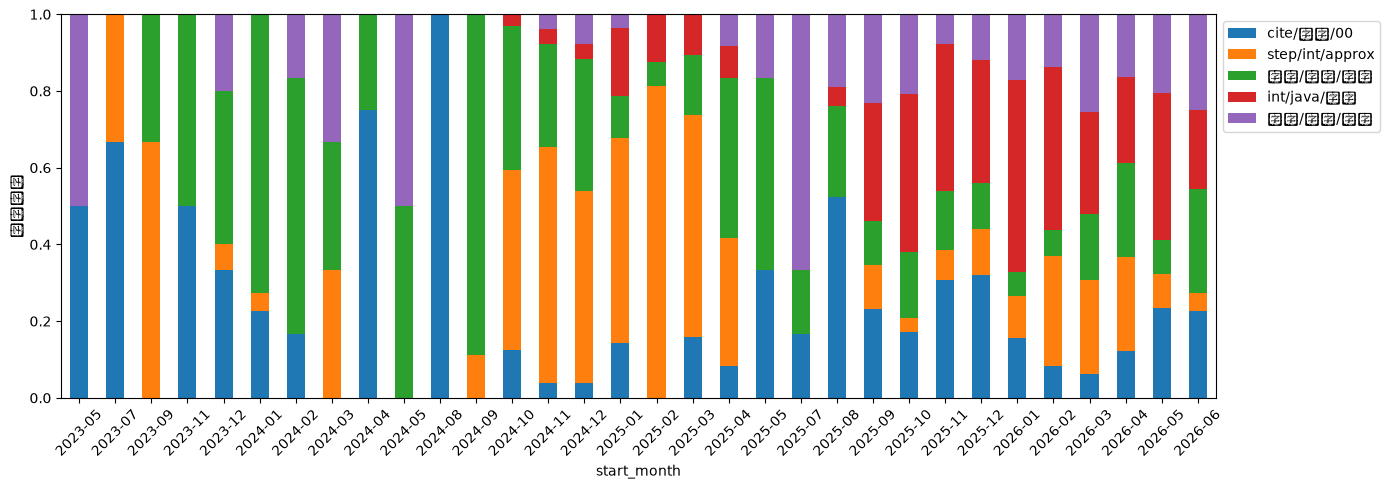


每月最偏好的话题:
2023-05: cite/日语/00 (50%)
2023-07: cite/日语/00 (67%)
2023-09: step/int/approx (67%)
2023-11: cite/日语/00 (50%)
2023-12: 可能/问题/研究 (40%)
2024-01: 可能/问题/研究 (73%)
2024-02: 可能/问题/研究 (67%)
2024-03: step/int/approx (33%)
2024-04: cite/日语/00 (75%)
2024-05: 可能/问题/研究 (50%)
2024-08: cite/日语/00 (100%)
2024-09: 可能/问题/研究 (89%)
2024-10: step/int/approx (47%)
2024-11: step/int/approx (62%)
2024-12: step/int/approx (50%)
2025-01: step/int/approx (54%)
2025-02: step/int/approx (81%)
2025-03: step/int/approx (58%)
2025-04: 可能/问题/研究 (42%)
2025-05: 可能/问题/研究 (50%)
2025-07: 游戏/视频/像素 (67%)
2025-08: cite/日语/00 (52%)
2025-09: int/java/逻辑 (31%)
2025-10: int/java/逻辑 (41%)
2025-11: int/java/逻辑 (38%)
2025-12: cite/日语/00 (32%)
2026-01: int/java/逻辑 (50%)
2026-02: int/java/逻辑 (42%)
2026-03: int/java/逻辑 (27%)
2026-04: step/int/approx (24%)
2026-05: int/java/逻辑 (38%)
2026-06: 可能/问题/研究 (27%)


In [240]:
conv_start_time = clean_df.groupby("conversation_id")["timestamp"].min()
conv_docs["start_month"] = conv_docs["conversation_id"].map(conv_start_time).dt.to_period("M").astype(str)

monthly_topic = conv_docs.groupby(["start_month", "cluster"]).size().unstack(fill_value=0)
monthly_topic_share = monthly_topic.div(monthly_topic.sum(axis=1), axis=0)

# 给每个簇起一个可读标签：用该簇的前3个c-TF-IDF关键词
cluster_labels = {}
for cluster_id in sorted(conv_docs["cluster"].unique()):
    mask = (conv_docs["cluster"] == cluster_id).values
    scores = tfidf[mask].mean(axis=0).A1
    top3 = [terms[i] for i in scores.argsort()[::-1][:3]]
    cluster_labels[cluster_id] = "/".join(top3)

monthly_topic_share.columns = [cluster_labels[c] for c in monthly_topic_share.columns]

fig, ax = plt.subplots(figsize=(14, 5))
monthly_topic_share.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("话题占比")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n每月最偏好的话题:")
dominant = monthly_topic_share.idxmax(axis=1)
for month, label in dominant.items():
    share = monthly_topic_share.loc[month, label]
    print(f"{month}: {label} ({share:.0%})")

## 重写率（不需要LLM，纯解析逻辑）

解析器现在给每行数据加了 `edit_count`：这条消息在 ChatGPT 的对话树里有几个"被放弃的兄弟分支"——`role=user` 的非零值代表你编辑/重发了这个问题几次，`role=assistant` 的非零值代表你点了几次"重新生成"。

要先重新跑一下读取 parquet 的 cell（`cd8a66b9`）和清洗异常点的 cell（`e6dcc5ed`），把新列加载进来——不需要重新跑embedding和聚类，那两步不依赖这个新列。

In [241]:
edited = clean_df[clean_df["edit_count"] > 0]
user_edits = edited[edited["role"] == "user"]
assistant_regens = edited[edited["role"] == "assistant"]

total_convs = clean_df["conversation_id"].nunique()
convs_with_edits = edited["conversation_id"].nunique()

print(f"有过编辑/重新生成的对话: {convs_with_edits}/{total_convs} ({convs_with_edits/total_convs:.1%})")
print(f"用户重写问题: {len(user_edits)} 个轮次涉及，累计被放弃的版本数 {user_edits['edit_count'].sum()}")
print(f"AI回复被重新生成: {len(assistant_regens)} 个轮次涉及，累计被放弃的版本数 {assistant_regens['edit_count'].sum()}")

print("\n被改写/重新生成最多次的几条消息:")
most_edited = clean_df.sort_values("edit_count", ascending=False).head(5)
print(most_edited[["conversation_id", "role", "edit_count", "text"]].to_string())

有过编辑/重新生成的对话: 96/741 (13.0%)
用户重写问题: 91 个轮次涉及，累计被放弃的版本数 107
AI回复被重新生成: 27 个轮次涉及，累计被放弃的版本数 30

被改写/重新生成最多次的几条消息:
                           conversation_id       role  edit_count                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

## 用 Gemini 给聚类簇起人类可读的名字

只发关键词，不发原始对话内容。结果缓存进 `llm_cluster_labels`，后面的图表和文字都用这个代替关键词拼接。

In [242]:
import sys
sys.path.append("..")
from src.llm.gemini_client import label_cluster

llm_cluster_labels = {}
for cluster_id in sorted(conv_docs["cluster"].unique()):
    mask = (conv_docs["cluster"] == cluster_id).values
    scores = tfidf[mask].mean(axis=0).A1
    top_keywords = [terms[i] for i in scores.argsort()[::-1][:10]]
    llm_cluster_labels[cluster_id] = label_cluster(top_keywords)
    print(cluster_id, "->", llm_cluster_labels[cluster_id], " (关键词:", top_keywords[:5], ")")

0 -> 学术交流与留学  (关键词: ['cite', '日语', '00', 'ubc', 'year'] )
1 -> 数值计算方法  (关键词: ['step', 'int', 'approx', 'bmatrix', 'left'] )
2 -> 科学研究与生物问题  (关键词: ['可能', '问题', '研究', '细胞', '影响'] )
3 -> 编程核心概念  (关键词: ['int', 'java', '逻辑', 'struct', 'void'] )
4 -> 游戏视觉与AI创作  (关键词: ['游戏', '视频', '像素', 'unity', '风格'] )


## 重新聚类：放大 k 搜索范围

741条对话内容跨度很大（数学、编程、生物、签证、日语课...），k=5太粗，会把不相关的内容硬挤进同一个簇。把搜索范围放大到 2~12，重新用 kneedle 选 k。

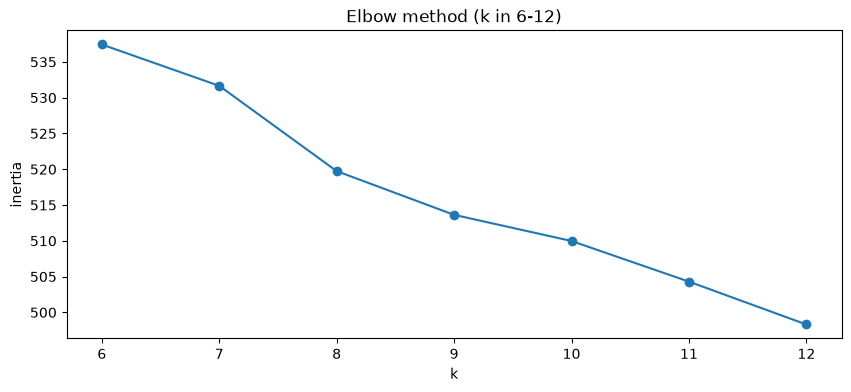

inertias: {6: 537.4, 7: 531.7, 8: 519.7, 9: 513.6, 10: 510.0, 11: 504.3, 12: 498.3}
auto-selected k: 8


In [243]:
k_range = list(range(6, 13))
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(embeddings)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow method (k in 6-12)")
plt.show()

x = np.array(k_range, dtype=float)
y = np.array(inertias, dtype=float)
x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())
line_vec = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
line_vec /= np.linalg.norm(line_vec)
distances = []
for xi, yi in zip(x_norm, y_norm):
    point_vec = np.array([xi - x_norm[0], yi - y_norm[0]])
    proj_len = np.dot(point_vec, line_vec)
    proj_point = proj_len * line_vec
    distances.append(np.linalg.norm(point_vec - proj_point))
best_k = k_range[int(np.argmax(distances))]
print("inertias:", dict(zip(k_range, [round(v, 1) for v in inertias])))
print("auto-selected k:", best_k)

## 用新 k 重新跑聚类 + 关键词（保留LaTeX符号）+ Gemini 短标签

只把 `text`（纯渲染残留，没有数学含义）当噪音过滤，`frac/cdot/sin/theta` 等留着——它们是"这是数学内容"的有效信号。

In [244]:
STOPWORDS = list(ENGLISH_STOP_WORDS | stopwordsiso.stopwords("zh") | {"text"})

km = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
conv_docs["cluster"] = km.fit_predict(embeddings)
print(conv_docs["cluster"].value_counts().sort_index())

tokenized_docs = [" ".join(jieba.cut(doc)) for doc in conv_docs["doc"]]
vectorizer = TfidfVectorizer(max_features=2000, stop_words=STOPWORDS)
tfidf = vectorizer.fit_transform(tokenized_docs)
terms = vectorizer.get_feature_names_out()

llm_cluster_labels = {}
for cluster_id in sorted(conv_docs["cluster"].unique()):
    mask = (conv_docs["cluster"] == cluster_id).values
    scores = tfidf[mask].mean(axis=0).A1
    top_keywords = [terms[i] for i in scores.argsort()[::-1][:10]]
    llm_cluster_labels[cluster_id] = label_cluster(top_keywords)
    print(cluster_id, f"({mask.sum()}个对话) ->", llm_cluster_labels[cluster_id], " 关键词:", top_keywords[:6])

cluster
0     73
1    106
2    142
3     75
4     96
5     86
6     73
7     90
Name: count, dtype: int64
0 (73个对话) -> 中日文化生活考究  关键词: ['中国', '日语', 'cite', '00', 'year', '时间']
1 (106个对话) -> 生物演化探索  关键词: ['基因', '细胞', '物种', '研究', '可能', 'dna']
2 (142个对话) -> 编程语言与数据结构  关键词: ['int', 'java', 'python', 'struct', 'void', 'ld']
3 (75个对话) -> 游戏视频艺术生成  关键词: ['视频', '游戏', '像素', '风格', 'unity', '角色']
4 (96个对话) -> 公式推导  关键词: ['frac', 'dx', 'bmatrix', '矩阵', 'cdot', 'mathbf']
5 (86个对话) -> 大学学生报税  关键词: ['cite', 'ubc', '邮件', '学生', 'cra', '加拿大']
6 (73个对话) -> 逻辑思辨与问题探究  关键词: ['逻辑', 'neg', '前提', '结论', '论证', '命题']
7 (90个对话) -> 统计与概率分析  关键词: ['frac', 'bar', '概率', 'mu', '分布', 'lambda']


## 按月抽样写"高光时刻"小结

每个月随机抽1条对话，把完整对话（user/assistant交替，按时间排序，截断到安全长度）发给 Gemini，让它用一句话写成年度报告里那种小故事式总结。先看效果，不追求覆盖所有月份的代表性。

In [282]:
import importlib
import src.llm.gemini_client
importlib.reload(src.llm.gemini_client)
from src.llm.gemini_client import summarize_highlight

def conversation_text(conv_id, max_chars=1500):
    rows = clean_df.loc[clean_df["conversation_id"] == conv_id].sort_values("timestamp")
    full = "\n".join(f"{row.role}: {row.text}" for row in rows.itertuples())
    return full[:max_chars]

rng_month = np.random.default_rng(42)
monthly_sample = (
    conv_docs.groupby("start_month")["conversation_id"]
    .apply(lambda ids: rng_month.choice(ids.values))
    .sort_index()
    .tail(12)
)

print("最近12个月抽样高光：\n")
for month, conv_id in monthly_sample.items():
    highlight = summarize_highlight(conversation_text(conv_id))
    print(f"{month}: {highlight}")

最近12个月抽样高光：

2025-07: 你询问了苹果手机备忘录为何无法扫描文件。
2025-08: 你寻求从零开始创建简历，并开始提供个人信息。
2025-09: 你向AI请教了VS Code中“工作区”的定义与作用。
2025-10: 你上传了文件，让AI阅读，并准备进一步指示具体分析方向。
2025-11: 你向AI请教了关于一个前件为矛盾式、后件为偶然式的条件句的类型及其原因。
2025-12: 你好奇地询问了两个全称量词逻辑表达式的等价性问题。
2026-01: 你询问了十六进制数除以二的幂的计算方法。
2026-02: 你请AI提供清炖排骨汤的详细做法，包括材料清单和各步骤时长。
2026-03: 你请AI阐释生物学中“analogous structures”的定义、例子，并与“homologous”作对比。
2026-04: 你寻求对统计学中F-value的全面解释，包括其核心定义、计算方式和直观理解。
2026-05: 你请AI分析一段C++代码的循环逻辑，并就其循环不变式与基线情况的关键点提出疑问。
2026-06: 你请AI详细解释了AVL树的概念、原理、平衡机制及旋转操作。
